<a href="https://colab.research.google.com/github/Nachos-mic/Lung_CT_Diagnostic_ML/blob/main/Lung_Diagnostics_MASKED_SLICE_FOCAL_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioteki


In [1]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import WeightedRandomSampler
import optuna
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, accuracy_score
import random
import torch.nn.functional as F
import cv2
import json
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


MERGED_STAGE_TO_LABEL = {
    'I': 0,
    'II': 1,
    'IIIa': 2,
    'IIIb': 2,
    'III': 2,
}
LABEL_TO_MERGED_STAGE = {
    0: 'I',
    1: 'II',
    2: 'III',
}
NUM_CLASSES = len(LABEL_TO_MERGED_STAGE)


def merge_stage_label(value):
    if pd.isna(value):
        raise ValueError('Missing stage or label value')

    if isinstance(value, str):
        normalized = value.strip()
        if normalized in MERGED_STAGE_TO_LABEL:
            return MERGED_STAGE_TO_LABEL[normalized]
        return 2 if normalized == 'III' else int(normalized)

    return 2 if int(value) == 3 else int(value)


Rozpakowanie danych do dysku (jednorazowe)

In [4]:
import zipfile
import os

from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/content/dataset_masked', exist_ok=True)

with zipfile.ZipFile('/content/drive/MyDrive/masked_lung_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_masked')

print("Gotowe!")
print(os.listdir('/content/dataset_masked'))

Mounted at /content/drive
Gotowe!
['data_2d_masked_ct', 'master_dataset.csv', 'train.csv', 'test.csv', 'val.csv', 'NSCLC-Radiomics-Lung1.clinical-data.csv']


In [ ]:
!ls "/content/drive/MyDrive/" | grep masked

ls: cannot access '/content/drive/MyDrive/': No such file or directory


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_4372/44401997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')


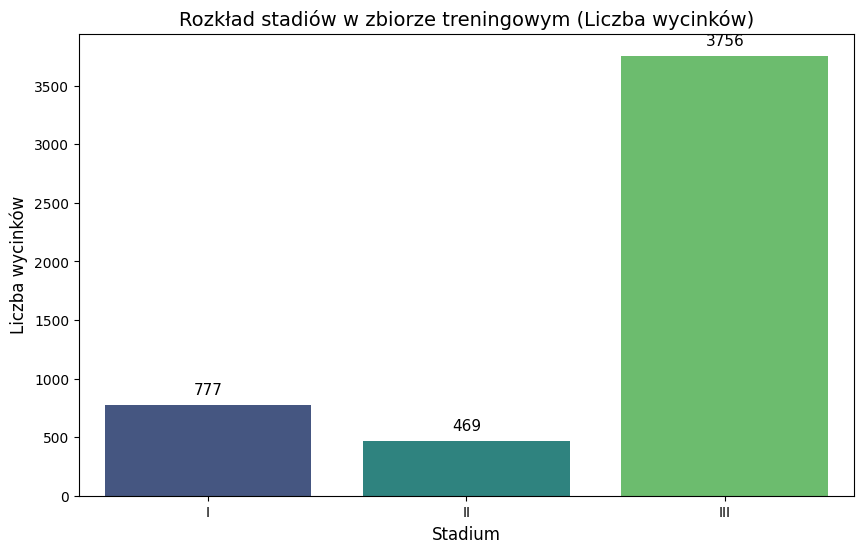


--- Przykładowe wycinki dla poszczególnych klas ---


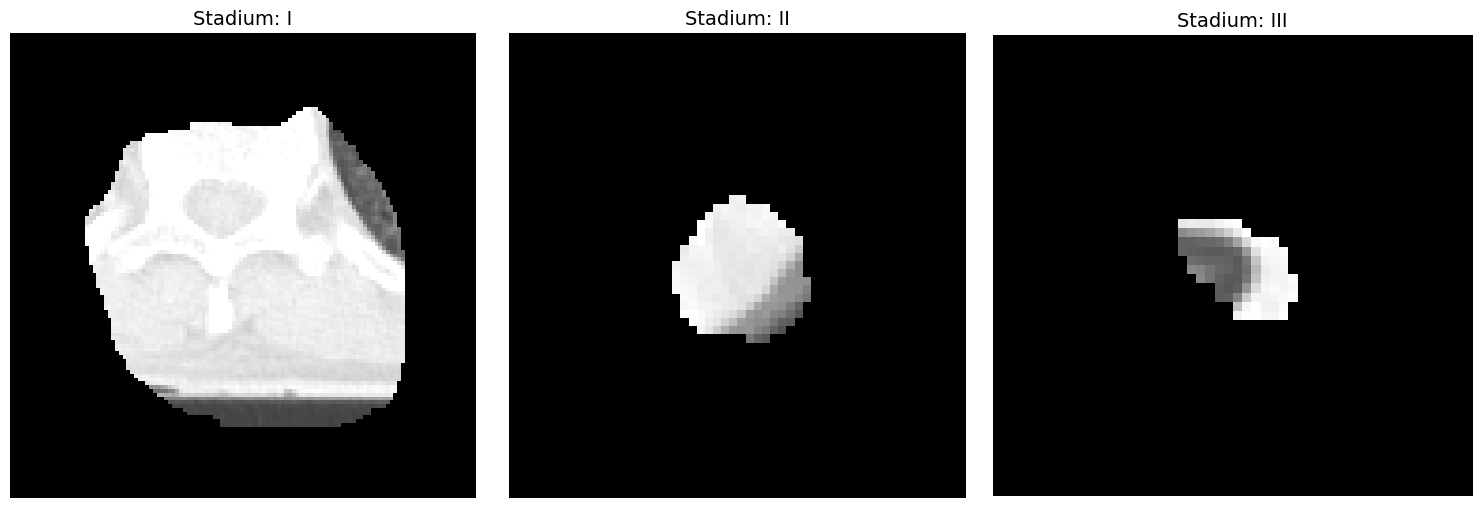

In [5]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset_masked/train.csv'

df_train = pd.read_csv(TRAIN_CSV)
df_train['merged_stage'] = df_train['original_stage'].replace({'IIIa': 'III', 'IIIb': 'III'})

# Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Wizualizacja przykładowych zdjęć dla każdej z 3 klas po połączeniu IIIa i IIIb
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stages = ['I', 'II', 'III']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['merged_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset_masked/data_2d_masked_ct', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

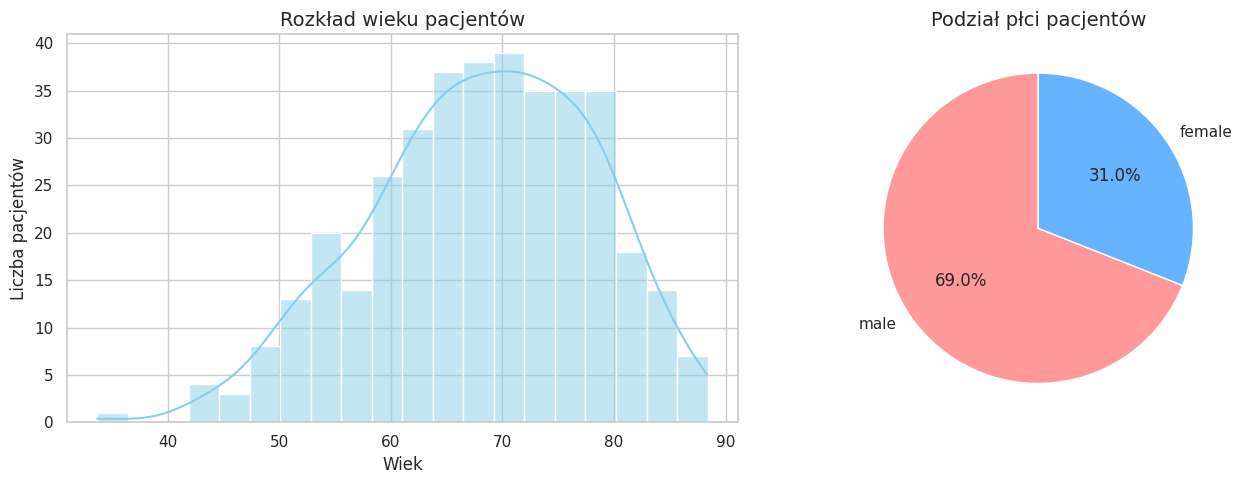

/tmp/ipykernel_4372/624192595.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


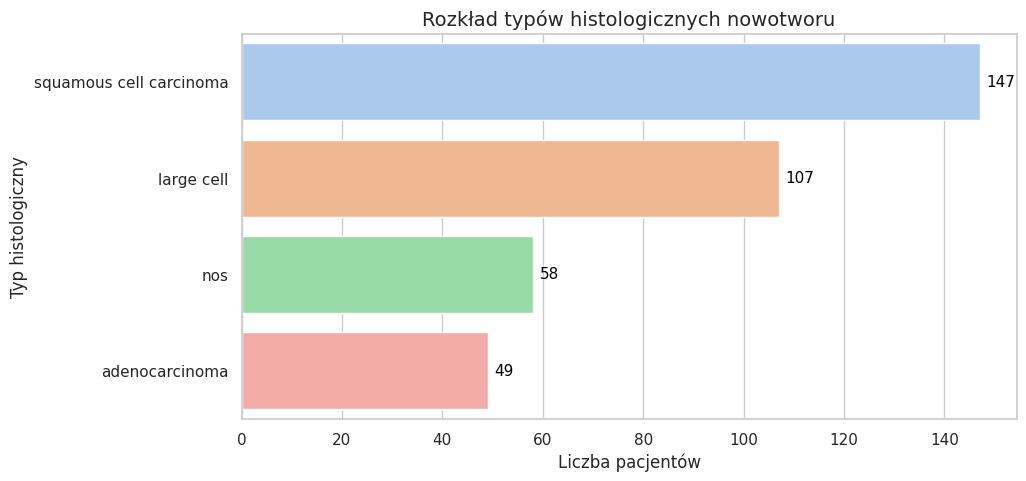

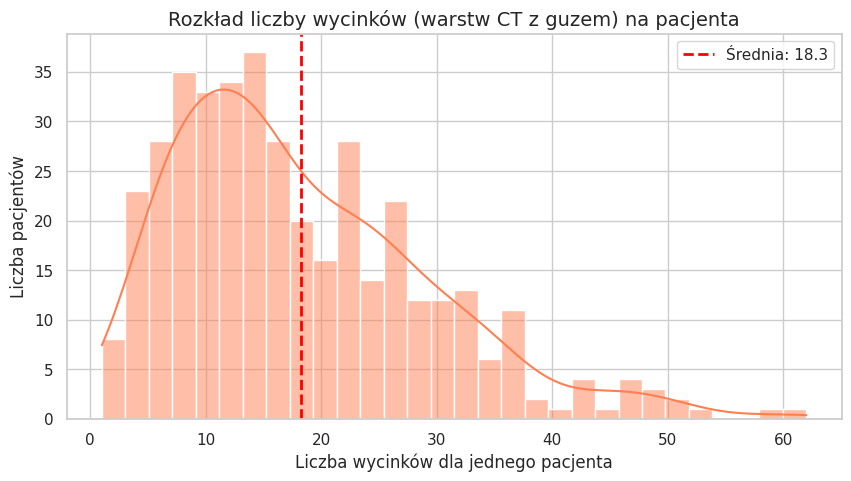

Całkowita liczba uwzględnionych pacjentów: 400
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 18.3
Pacjent z najmniejszą liczbą wycinków ma ich: 1
Pacjent z największą liczbą wycinków ma ich: 62


In [6]:

MASTER_CSV = r"/content/dataset_masked/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset_masked/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

# PROTO - dodanie wieku i innych cech:



In [7]:
# Wczytanie i przygotowanie metadanych klinicznych
df_clinical = pd.read_csv('/content/dataset_masked/NSCLC-Radiomics-Lung1.clinical-data.csv')

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()

# Wczytanie pacjentów tylko ze zbioru treningowego
df_train_for_leak = pd.read_csv('/content/dataset_masked/train.csv')
train_patient_ids = df_train_for_leak['patient_id'].astype(str).str.strip().unique()

train_clinical = df_clinical[df_clinical['PatientID'].isin(train_patient_ids)]
age_mean = train_clinical['age'].mean()
age_std = train_clinical['age'].std()

# Aplikacja normalizacji na WSZYSTKICH pacjentów (Train, Val, Test) używając parametrów treningowych
df_clinical['age_norm'] = (df_clinical['age'] - age_mean) / age_std

df_clinical['gender_bin'] = df_clinical['gender'].map({'male': 0.0, 'female': 1.0}).fillna(0.0)
clinical_features = df_clinical[['PatientID', 'age_norm', 'gender_bin']]

Preprocessing do ResNet

In [8]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08))
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms dla masked CT gotowe!")

Transforms dla masked CT gotowe!


Klasa Dataset

In [9]:
class LungCancerHybridDataset(Dataset):
    def __init__(self, csv_file, clinical_df, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Merge z danymi klinicznymi
        self.data_frame = self.data_frame.merge(
            clinical_df[['PatientID', 'age_norm', 'gender_bin']],
            left_on='patient_id', right_on='PatientID', how='left'
        )

        self.data_frame['age_norm'] = self.data_frame['age_norm'].fillna(0.0)
        self.data_frame['gender_bin'] = self.data_frame['gender_bin'].fillna(0.0)

        # Mapowanie etykiet
        label_col = 'original_stage' if 'original_stage' in self.data_frame.columns else 'label'
        self.data_frame['merged_label'] = self.data_frame[label_col].apply(merge_stage_label)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]

        # Obraz
        filename = os.path.basename(row['image_path'].replace('\\', '/'))
        img_path = os.path.join(self.root_dir, filename)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Dane kliniczne (Wiek, Płeć)
        clinical_vec = torch.tensor([row['age_norm'], row['gender_bin']], dtype=torch.float32)

        # Etykieta
        label = int(row['merged_label'])

        return image, clinical_vec, label



DataLoaders i WeightedSampler


In [10]:
from posix import truncate
from sklearn.utils.class_weight import compute_class_weight
IMG_DIR_COLAB = '/content/dataset_masked/data_2d_masked_ct'

# Tworzenie instancji hybrydowych datasetów
train_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/train.csv',
                                        clinical_df=clinical_features,
                                        root_dir=IMG_DIR_COLAB,
                                        transform=train_transforms)

val_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/val.csv',
                                      clinical_df=clinical_features,
                                      root_dir=IMG_DIR_COLAB,
                                      transform=val_test_transforms)

test_dataset = LungCancerHybridDataset(csv_file='/content/dataset_masked/test.csv',
                                       clinical_df=clinical_features,
                                       root_dir=IMG_DIR_COLAB,
                                       transform=val_test_transforms)

# Weighted Sampler - Balansowanie klas I, II, III
train_labels = train_dataset.data_frame['merged_label'].values
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = torch.from_numpy(class_weights[train_labels]).type(torch.DoubleTensor)

CT_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# OBLICZENIE WAG DLA FUNKCJI STRATY
# Używamy dokładnie tej nazwy kolumny, którą miałeś w samplerze: 'merged_label'
train_labels_for_loss = train_dataset.data_frame['merged_label'].values

computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_for_loss),
    y=train_labels_for_loss
)

print(f"\nWyliczone wagi klas dla Loss Function (I, II, III): {computed_weights}")

# Weryfikacja
sample_batch = next(iter(train_loader))
print(f"Batch obrazów: {sample_batch[0].shape}")
print(f"Batch danych klinicznych: {sample_batch[1].shape}") # Powinno być [32, 2]
print(f"Batch etykiet: {sample_batch[2].shape}")
print("\nDane gotowe do treningu hybrydowego!")


Wyliczone wagi klas dla Loss Function (I, II, III): [2.14586015 3.55508173 0.44391196]
Batch obrazów: torch.Size([32, 3, 224, 224])
Batch danych klinicznych: torch.Size([32, 2])
Batch etykiet: torch.Size([32])

Dane gotowe do treningu hybrydowego!


Focal Loss

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

Trening ResNet- 18

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

class ResNetHybrid(nn.Module):
    def __init__(self, num_classes=3, hidden_units=512, dropout_rate=0.4):
        super(ResNetHybrid, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs + 2, hidden_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_units, num_classes)
        )

    def forward(self, img, clinical):
        img_features = self.backbone(img)
        combined     = torch.cat((img_features, clinical), dim=1)
        return self.classifier(combined)

# model = ResNetHybrid(num_classes=3, dropout_rate=0.4)

# for param in model.parameters():
#     param.requires_grad = False
# for param in model.backbone.layer3.parameters():
#     param.requires_grad = True
# for param in model.backbone.layer4.parameters():
#     param.requires_grad = True
# for param in model.classifier.parameters():
#     param.requires_grad = True

# model = model.to(device)

# train_labels  = train_dataset.data_frame['merged_label'].values
# class_counts  = np.bincount(train_labels)
# soft_weights  = 1.0 / np.sqrt(class_counts)
# soft_weights  = soft_weights / soft_weights.sum() * 3
# weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)
# criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# optimizer = optim.Adam([
#     {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
#     {'params': model.backbone.layer4.parameters(), 'lr': 5e-6},
#     {'params': model.classifier.parameters(),      'lr': 1e-3}
# ], weight_decay=1e-3)

# print("Setup: Baseline CrossEntropy gotowy!")

Używane urządzenie: cuda


Pętla ucząca

In [ ]:
# konfiguracja treninigu
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
best_auc = 0.0
best_f1 = 0.0
best_acc = 0.0
results_path = 'best_metrics.txt'

with open(results_path, 'w') as f:
    f.write("REKORDY MODELU HYBRYDOWEGO (NSCLC STAGING)\n")


history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_auc': [], 'val_auc': []
}

NUM_EPOCHS = 20

# --- KONFIGURACJA EARLY STOPPING ---
patience = 10
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'Epoka {epoch+1}/{NUM_EPOCHS}')

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader

        running_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []

        for inputs, clinical_data, labels in dataloader:
            inputs, clinical_data, labels = inputs.to(device), clinical_data.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs, clinical_data)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            epoch_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            epoch_auc = 0.0

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        history[f'{phase}_f1'].append(epoch_f1)
        history[f'{phase}_auc'].append(epoch_auc)

        print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f} | AUC: {epoch_auc:.4f}')

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc

            # Rejestrowanie rekordu AUC (bez zapisu modelu)
            if epoch_auc > best_auc:
                best_auc = epoch_auc
                print(f"*** Nowy rekord AUC: {best_auc:.4f} ***")

            # Zapis modelu i Early Stopping na podstawie F1
            if epoch_f1 > best_f1:
                best_f1 = epoch_f1
                torch.save(model.state_dict(), 'best_hybrid_f1.pth')
                print(f"*** Zapisano model (Nowy rekord F1: {best_f1:.4f}) ***")
                epochs_no_improve = 0  # Resetujemy licznik cierpliwości
            else:
                epochs_no_improve += 1

    # Sprawdzenie warunku Early Stopping po zakończeniu obu faz (train i val) w epoce
    if epochs_no_improve >= patience:
        print(f"\n[Early Stopping] Brak poprawy F1 od {patience} epok. Przerwano trening.")
        break

    print()

# Ewaluacja
print("\nRaport klasyfikacji")

# WAŻNE: Wczytujemy model zapisany na podstawie najlepszego wyniku F1
model.load_state_dict(torch.load('best_hybrid_f1.pth'))
model.eval()

final_preds, final_labels, final_probs = [], [], []

with torch.no_grad():
    for inputs, clinical_data, labels in val_loader:
        inputs, clinical_data = inputs.to(device), clinical_data.to(device)
        outputs = model(inputs, clinical_data)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())
        final_probs.extend(probs.cpu().numpy())

final_auc = roc_auc_score(final_labels, final_probs, multi_class='ovr', average='macro')
final_acc = accuracy_score(final_labels, final_preds)

print(f"\nOstateczny wynik AUC: {final_auc:.4f}")
print(f"Ostateczny wynik Acc: {final_acc:.4f}")
print(f"Referencyjny wynik z publikacji (RF): 0.881")
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(final_labels, final_preds, target_names=target_names))

cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek (Final AUC: {final_auc:.4f} | Acc: {final_acc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

# Soft-voting na poziomie pacjentów

df_val_results = val_dataset.data_frame.copy()

df_val_results['prob_I'] = [p[0] for p in final_probs]
df_val_results['prob_II'] = [p[1] for p in final_probs]
df_val_results['prob_III'] = [p[2] for p in final_probs]
df_val_results['true_label'] = final_labels

patient_level_df = df_val_results.groupby('patient_id').agg({
    'prob_I': 'mean',
    'prob_II': 'mean',
    'prob_III': 'mean',
    'true_label': 'first'
}).reset_index()

patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds = np.argmax(patient_probs, axis=1)
patient_true = patient_level_df['true_label'].values

patient_acc = accuracy_score(patient_true, patient_preds)
patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')

print(" Wyniki soft-voting na zbiorze walidacyjnym")
print(" (Agregacja 2D -> 3D za pomocą Soft Voting)")
print(f"PATIENT AUC: {patient_auc:.4f} (Wynik referencyjny z publikacji: 0.881)")
print(f"PATIENT ACC: {patient_acc:.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek - Pacjenci (Patient AUC: {patient_auc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

Epoka 1/20
TRAIN Loss: 0.9749 | Acc: 0.6957 | F1: 0.4243 | AUC: 0.6238
VAL Loss: 0.8119 | Acc: 0.6738 | F1: 0.3894 | AUC: 0.7319
*** Nowy rekord AUC: 0.7319 ***
*** Zapisano model (Nowy rekord F1: 0.3894) ***

Epoka 2/20
TRAIN Loss: 0.8947 | Acc: 0.7379 | F1: 0.4769 | AUC: 0.6970
VAL Loss: 0.7718 | Acc: 0.7216 | F1: 0.4873 | AUC: 0.7639
*** Nowy rekord AUC: 0.7639 ***
*** Zapisano model (Nowy rekord F1: 0.4873) ***

Epoka 3/20
TRAIN Loss: 0.8556 | Acc: 0.7417 | F1: 0.5055 | AUC: 0.7330
VAL Loss: 0.7405 | Acc: 0.7438 | F1: 0.4384 | AUC: 0.7597

Epoka 4/20
TRAIN Loss: 0.8391 | Acc: 0.7541 | F1: 0.5383 | AUC: 0.7350
VAL Loss: 0.7423 | Acc: 0.7293 | F1: 0.4863 | AUC: 0.7529

Epoka 5/20


KeyboardInterrupt: 

Krzywa uczenia i straty

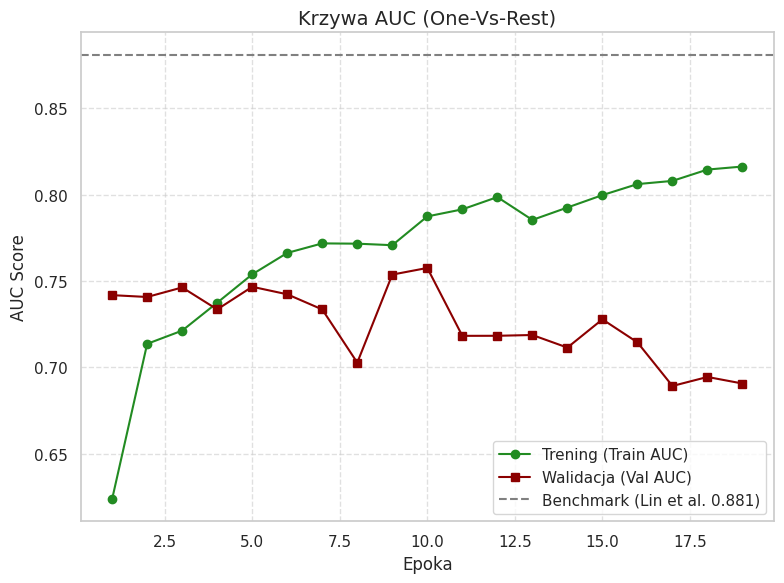

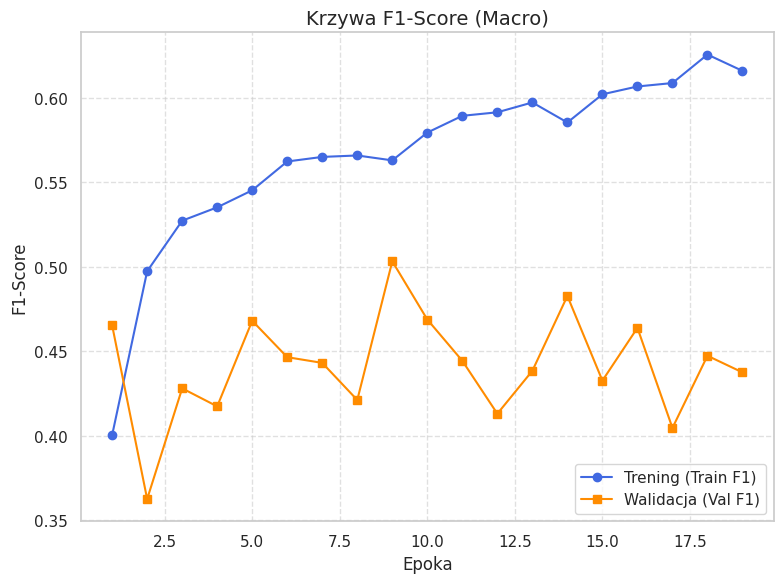

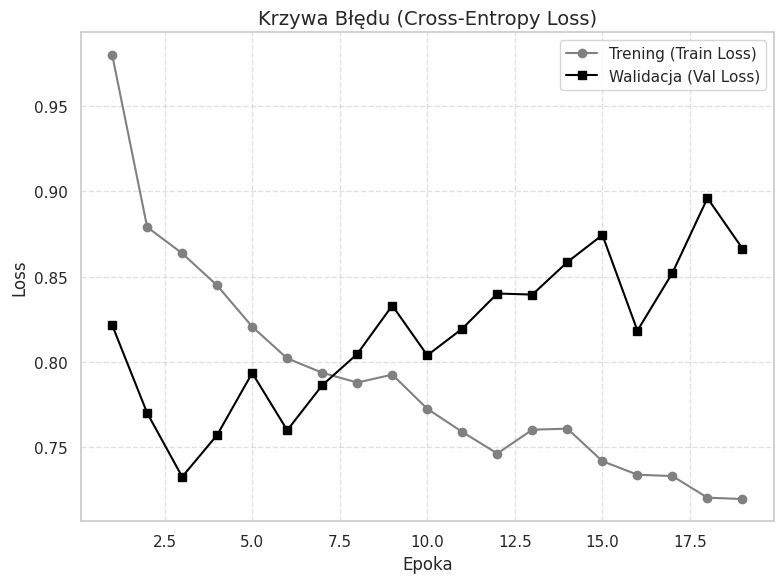

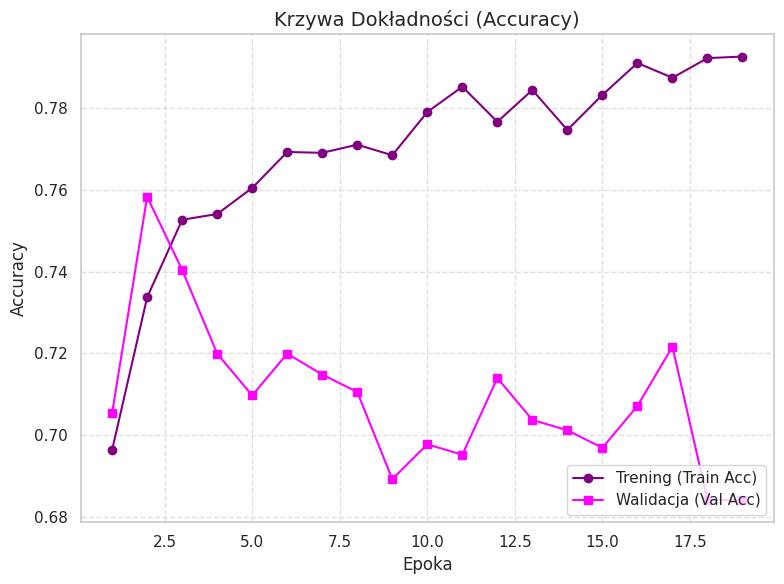

In [ ]:
epochs_range = range(1, len(history['train_f1']) + 1)

#  AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_auc', [0]*len(epochs_range)), label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history.get('val_auc', [0]*len(epochs_range)), label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC (One-Vs-Rest)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_auc.png', dpi=300, bbox_inches='tight')
plt.show()


# F1-Score (Macro Average)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# Funkcja błędu (Loss)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_loss', [0]*len(epochs_range)), label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history.get('val_loss', [0]*len(epochs_range)), label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu (Cross-Entropy Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy (Dokładność)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_acc', [0]*len(epochs_range)), label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history.get('val_acc', [0]*len(epochs_range)), label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Grad-Cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


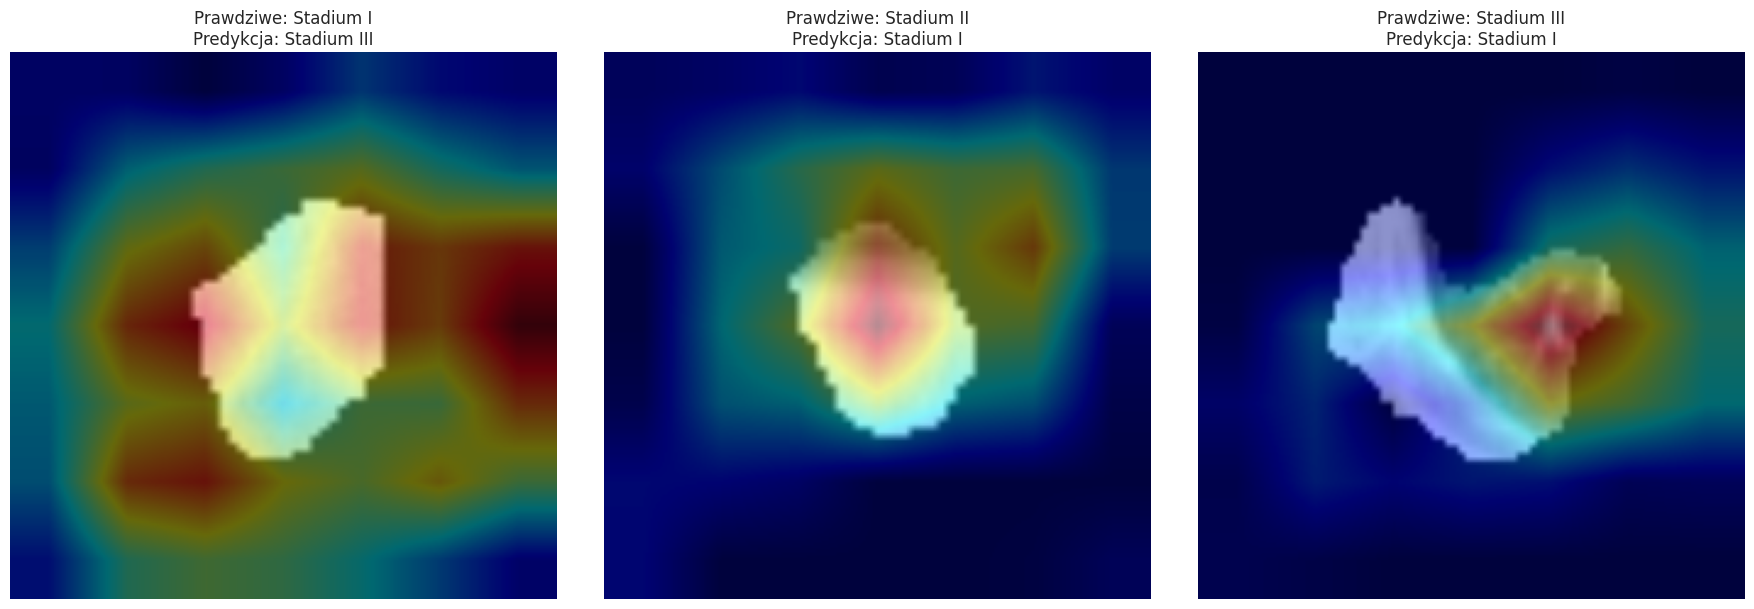

In [ ]:
def generate_gradcam(model, input_img, clinical_data, target_layer):
    model.eval()

    feature_blobs = []
    gradients = []

    def hook_feature(module, input, output):
        feature_blobs.append(output.cpu().data.numpy())

    def hook_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0].cpu().data.numpy())

    handle_forward = target_layer.register_forward_hook(hook_feature)
    handle_backward = target_layer.register_backward_hook(hook_gradient)

    output = model(input_img, clinical_data)
    _, target_class = torch.max(output, 1)

    model.zero_grad()
    output[0, target_class].backward()

    # Wyznaczanie wag i mapy ciepła
    grads = gradients[0]
    weights = np.mean(grads, axis=(2, 3))[0]
    features = feature_blobs[0][0]

    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

    handle_forward.remove()
    handle_backward.remove()

    return cam, target_class.item()

def show_gradcam_gallery(model, dataset):
    # Szukamy po jednym przykładzie dla każdego stadium (0, 1, 2)
    indices = []
    for target_label in [0, 1, 2]:
        for i in range(len(dataset)):
            _, _, label = dataset[i]
            if label == target_label:
                indices.append(i)
                break

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    target_names = ['Stadium I', 'Stadium II', 'Stadium III']

    for i, idx in enumerate(indices):
        img_tensor, clinical_tensor, label = dataset[idx]

        input_img = img_tensor.unsqueeze(0).to(device)
        clinical_data = clinical_tensor.unsqueeze(0).to(device)

        heatmap, pred_class = generate_gradcam(model, input_img, clinical_data, model.backbone.layer4)

        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_show + 0.4 * heatmap_color

        axes[i].imshow(overlay)
        axes[i].set_title(f"Prawdziwe: {target_names[label]}\nPredykcja: {target_names[pred_class]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Wywołanie
show_gradcam_gallery(model, val_dataset)

# Optuna


Tutaj celujemy w usprawnienie F1 jako metryki dla slice'ów

In [14]:
"""
OPTUNA HPO — Eksperyment 2 (Masked CT) — v2
Optymalizacja pod val F1 (slice-level, Macro) — spójne z Full Slices
15 triali × 15 epok

Zapis do: best_optuna_params_masked_focal_f1.json
"""

import optuna
import json
import numpy as np
import torch
import torch.optim as optim
import os
from sklearn.metrics import f1_score

SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS_PER_TRIAL = 20


def objective(trial):
    gamma        = trial.suggest_float("gamma",        1.3,  1.7)
    lr_fc        = trial.suggest_float("lr_fc",        8e-4, 2e-3, log=True)
    lr_layer4    = trial.suggest_float("lr_layer4",    3e-6, 2e-5, log=True)
    lr_layer3    = trial.suggest_float("lr_layer3",    5e-7, 8e-6, log=True)
    weight_decay = trial.suggest_float("weight_decay", 5e-4, 5e-3, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.30, 0.50)

    model = ResNetHybrid(num_classes=3, dropout_rate=dropout_rate).to(device)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.layer3.parameters():
        param.requires_grad = True
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    train_labels   = train_dataset.data_frame['merged_label'].values
    class_counts   = np.bincount(train_labels)
    soft_weights   = 1.0 / np.sqrt(class_counts)
    soft_weights   = soft_weights / soft_weights.sum() * 3
    weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

    criterion = FocalLoss(gamma=gamma, weight=weights_tensor)

    optimizer = optim.Adam([
        {'params': model.backbone.layer3.parameters(), 'lr': lr_layer3},
        {'params': model.backbone.layer4.parameters(), 'lr': lr_layer4},
        {'params': model.classifier.parameters(),      'lr': lr_fc}
    ], weight_decay=weight_decay)

    best_trial_f1 = 0.0

    for epoch in range(EPOCHS_PER_TRIAL):
        model.train()
        for inputs, clinical_data, labels in train_loader:
            inputs        = inputs.to(device)
            clinical_data = clinical_data.to(device)
            labels        = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, clinical_data)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        all_labels, all_preds = [], []

        with torch.no_grad():
            for inputs, clinical_data, labels in val_loader:
                inputs        = inputs.to(device)
                clinical_data = clinical_data.to(device)
                outputs       = model(inputs, clinical_data)
                _, preds      = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds,
                           average='macro', labels=[0, 1, 2], zero_division=0)

        if val_f1 > best_trial_f1:
            best_trial_f1 = val_f1

        print(f"  Trial {trial.number} | E{epoch+1:02} | F1: {val_f1:.4f} | Best: {best_trial_f1:.4f}")

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_trial_f1


def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | F1: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open(f'{SAVE_DIR}/best_optuna_params_masked_focal_f1.json', 'w') as fp:
            json.dump(study.best_params, fp, indent=2)
        import shutil
        shutil.copy(
            '/content/optuna_masked_focal_f1_v1.db',
            f'{SAVE_DIR}/optuna_masked_focal_f1_v1.db'
        )


study = optuna.create_study(
    direction="maximize",
    study_name="ResNetHybrid_Masked_Focal_F1_V1",
    storage="sqlite:////content/optuna_masked_focal_f1_v1.db",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=4)
)

print(f"Triali w bazie: {len(study.trials)}")

study.optimize(
    objective,
    n_trials=15,
    timeout=36000,
    callbacks=[save_callback]
)

print(f"\nNajlepszy F1: {study.best_value:.4f}")
print("Najlepsze parametry:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

with open(f'{SAVE_DIR}/best_optuna_params_masked_focal_f1.json', 'w') as fp:
    json.dump(study.best_params, fp, indent=2)
print(f"\nParametry zapisane: {SAVE_DIR}/best_optuna_params_masked_focal_f1.json")

[I 2026-04-26 16:19:47,380] A new study created in RDB with name: ResNetHybrid_Masked_Focal_NoBlur_V1


Triali w bazie: 0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 229MB/s]
[W 2026-04-26 16:19:48,836] Trial 0 failed with parameters: {'gamma': 1.6700111889152058, 'lr_fc': 0.0015948472578105367, 'lr_layer4': 9.179277990857855e-06, 'lr_layer3': 1.5153688595945324e-06, 'weight_decay': 0.0015242989425512216, 'dropout_rate': 0.3255085457272814} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_4372/2653448465.py", line 53, in objective
    outputs = model(inputs, clinical_data)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.

KeyboardInterrupt: 

Params warte uwagi:

[I 2026-04-25 20:57:56,482] Trial 12 finished with value: 0.7666462436053448 and parameters: {'lr_fc': 0.001550818708025384, 'lr_layer4': 6.082341230733749e-06, 'lr_layer3': 1.3714113867388413e-06, 'weight_decay': 0.002690462855005448, 'dropout_rate': 0.3744654920089184}. Best is trial 12 with value: 0.7666462436053448.

Finałowy trening oraz soft-voting

Urządzenie: cuda
Wczytane parametry (Masked CT Focal): {'gamma': 1.5461193874061445, 'lr_fc': 0.0015694954884747988, 'lr_layer4': 1.4619478616188916e-05, 'lr_layer3': 5.2720749096987e-07, 'weight_decay': 0.0012886977292786823, 'dropout_rate': 0.3319447425527677}

Wycinki w klasach (I, II, III): [ 777  469 3756]
Soft wagi: [1.0941 1.4083 0.4976]
Criterion: FocalLoss gamma=1.5461
Optimizer: Adam lr_layer3=5.27e-07 lr_layer4=1.46e-05 lr_fc=1.57e-03 weight_decay=1.29e-03

Epoka  T-Loss    V-Loss    V-AUC (slice)   PAT-AUC    PAT-F1    Best PAT-AUC
────────────────────────────────────────────────────────────────────────────────
E01   | 0.3252    0.3032    0.7155          0.7288     0.4269    0.0000
      ✓ Nowy rekord Patient AUC: 0.7288 — zapisano
      ✓ Nowy rekord Patient F1:  0.4269 — zapisano
E02   | 0.2775    0.3284    0.7254          0.7541     0.3958    0.7288
      ✓ Nowy rekord Patient AUC: 0.7541 — zapisano
E03   | 0.2631    0.2946    0.6944          0.7211     0.3961    0.7541


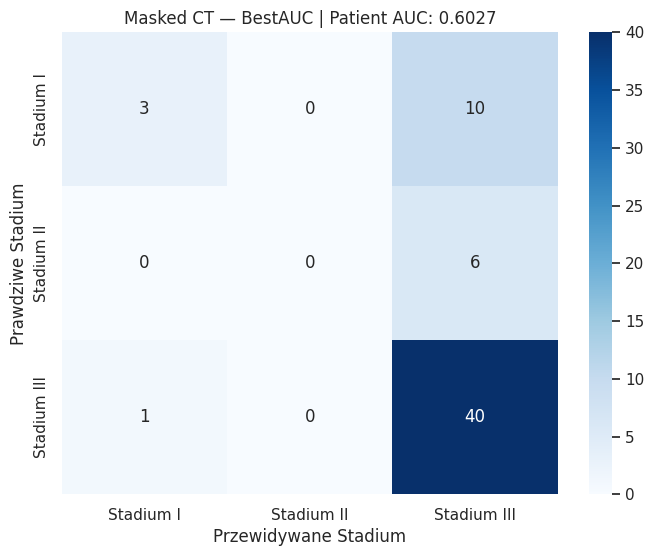

Zapisano: /content/drive/MyDrive/masked_ct_models/cm_masked_BestAUC.png

────────────────────────────────────────────────────────────
Ewaluacja: BestF1  (z TTA)
────────────────────────────────────────────────────────────
PATIENT AUC : 0.6519   (Benchmark: 0.881)
PATIENT F1  : 0.4857
PATIENT ACC : 0.6333

              precision    recall  f1-score   support

   Stadium I     0.3333    0.5385    0.4118        13
  Stadium II     1.0000    0.1667    0.2857         6
 Stadium III     0.7895    0.7317    0.7595        41

    accuracy                         0.6333        60
   macro avg     0.7076    0.4789    0.4857        60
weighted avg     0.7117    0.6333    0.6368        60



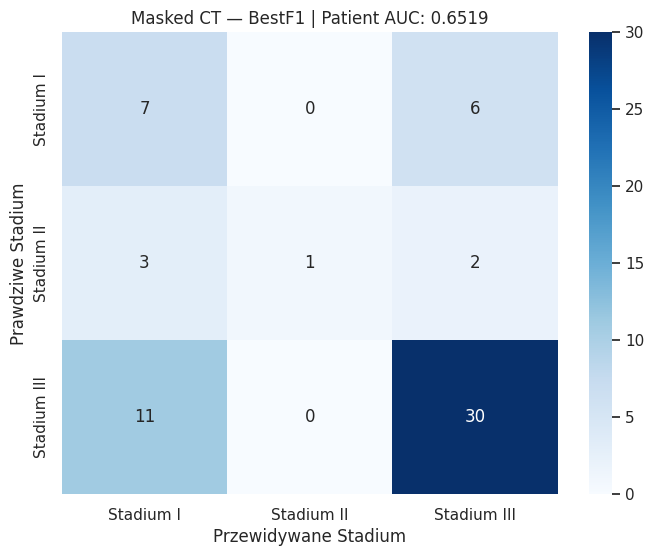

Zapisano: /content/drive/MyDrive/masked_ct_models/cm_masked_BestF1.png


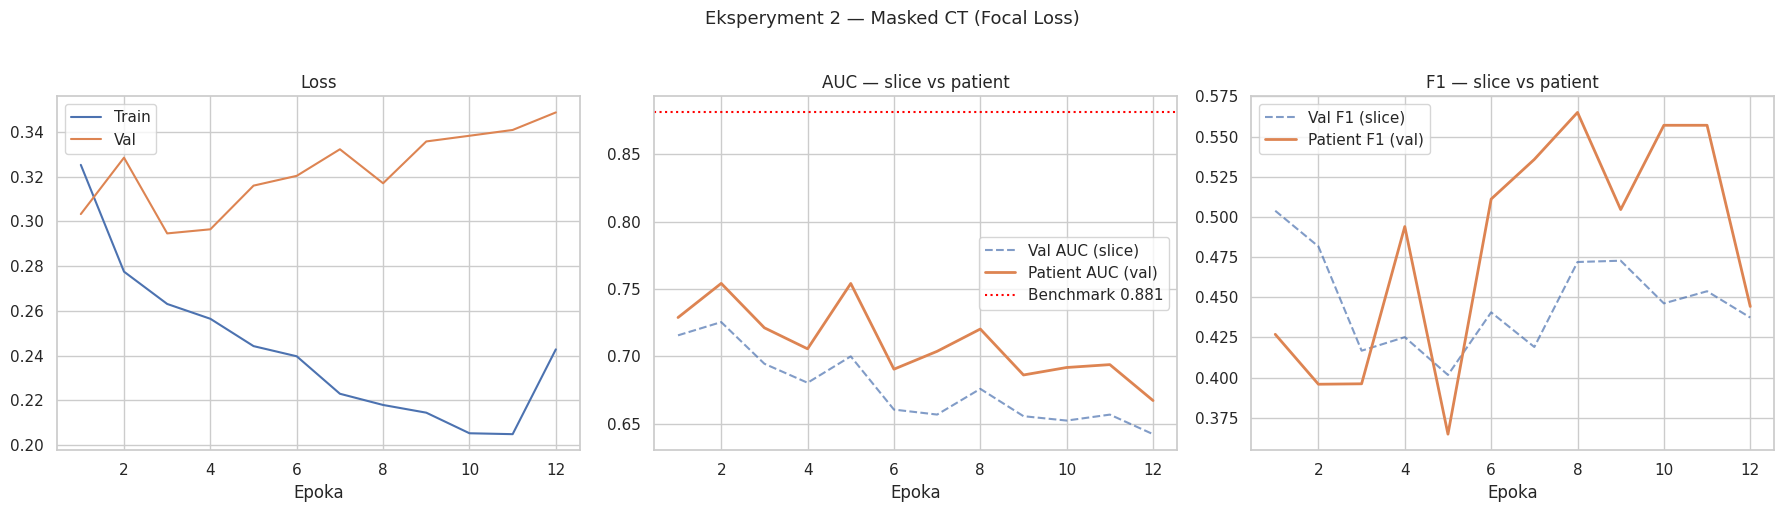

Historia treningu zapisana: /content/drive/MyDrive/masked_ct_models/training_history_masked_focal.png


In [ ]:
"""
FINALNY TRENING — Eksperyment 2 (Masked CT) — v5
ResNetHybrid, Focal Loss, IMAGE_SIZE=224, best_params z Optuny (F1)

Pipeline (spójny z Full Slices):
  1. Trening z early stopping na slice-level Macro F1
  2. Raport slice-level: val set + test set
  3. Soft-voting patient-level: test set (bez TTA + z TTA n=5)
  4. Tabela podsumowująca
  5. Historia treningu
"""

import os
import json
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from torchvision import transforms as T

SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'
os.makedirs(SAVE_DIR, exist_ok=True)

target_names = ['Stadium I', 'Stadium II', 'Stadium III']

# ──────────────────────────────────────────────────────────────────────────────
# WCZYTANIE PARAMETRÓW Z OPTUNY (F1)
# ──────────────────────────────────────────────────────────────────────────────

with open(f'{SAVE_DIR}/best_optuna_params_masked_focal_f1.json', 'r') as fp:
    best_params = json.load(fp)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie: {device}")
print(f"Parametry (Optuna F1): {best_params}\n")

# ──────────────────────────────────────────────────────────────────────────────
# SETUP MODELU
# ──────────────────────────────────────────────────────────────────────────────

model = ResNetHybrid(
    num_classes=3,
    dropout_rate=best_params.get('dropout_rate', 0.4)
).to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

train_labels   = train_dataset.data_frame['merged_label'].values
class_counts   = np.bincount(train_labels)
soft_weights   = 1.0 / np.sqrt(class_counts)
soft_weights   = soft_weights / soft_weights.sum() * 3
weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

print(f"Wycinki (I, II, III): {class_counts}")
print(f"Soft wagi: {soft_weights.round(4)}")

criterion = FocalLoss(
    gamma=best_params.get('gamma', 1.5),
    weight=weights_tensor
)
print(f"FocalLoss gamma={best_params.get('gamma', 1.5):.4f}")

optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(),
     'lr': best_params.get('lr_layer3', 1e-6)},
    {'params': model.backbone.layer4.parameters(),
     'lr': best_params.get('lr_layer4', 5e-6)},
    {'params': model.classifier.parameters(),
     'lr': best_params.get('lr_fc', 1e-3)}
], weight_decay=best_params.get('weight_decay', 1e-3))

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

# ──────────────────────────────────────────────────────────────────────────────
# PĘTLA TRENINGOWA — early stopping na slice-level F1
# ──────────────────────────────────────────────────────────────────────────────

NUM_EPOCHS = 30
PATIENCE   = 10

best_slice_f1    = 0.0
best_slice_auc   = 0.0
patience_counter = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_auc':  [], 'val_auc':  [],
    'train_f1':   [], 'val_f1':   [],
    'train_acc':  [], 'val_acc':  [],
}

print(f"\n{'Epoka':<6} {'T-Loss':<9} {'V-Loss':<9} {'V-AUC':<9} "
      f"{'V-F1':<9} {'Best F1'}")
print("─" * 60)

for epoch in range(NUM_EPOCHS):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    all_labels, all_probs, all_preds = [], [], []

    for inputs, clinical, labels in train_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        labels   = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, clinical)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    scheduler.step(epoch)

    train_loss = running_loss / len(train_loader.dataset)
    try:
        train_auc = roc_auc_score(all_labels, all_probs,
                                   multi_class='ovr', average='macro')
    except ValueError:
        train_auc = 0.0
    train_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_acc = accuracy_score(all_labels, all_preds)

    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['train_f1'].append(train_f1)
    history['train_acc'].append(train_acc)

    # ── VAL ───────────────────────────────────────────────────────────────────
    model.eval()
    v_loss = 0.0
    v_labels, v_preds, v_probs = [], [], []

    with torch.no_grad():
        for inputs, clinical, labels in val_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            labels   = labels.to(device)
            outputs  = model(inputs, clinical)
            loss     = criterion(outputs, labels)
            v_loss  += loss.item() * inputs.size(0)
            probs    = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            v_labels.extend(labels.cpu().numpy())
            v_preds.extend(preds.cpu().numpy())
            v_probs.extend(probs.cpu().numpy())

    val_loss = v_loss / len(val_loader.dataset)
    try:
        val_auc = roc_auc_score(v_labels, v_probs,
                                 multi_class='ovr', average='macro')
    except ValueError:
        val_auc = 0.0
    val_f1  = f1_score(v_labels, v_preds, average='macro', zero_division=0)
    val_acc = accuracy_score(v_labels, v_preds)

    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)

    if val_auc > best_slice_auc:
        best_slice_auc = val_auc

    print(f"E{epoch+1:02d}   | {train_loss:<9.4f} {val_loss:<9.4f} "
          f"{val_auc:<9.4f} {val_f1:<9.4f} {best_slice_f1:.4f}")

    # ── CHECKPOINTY + EARLY STOPPING na slice F1 ──────────────────────────────
    if val_f1 > best_slice_f1:
        best_slice_f1 = val_f1
        torch.save(model.state_dict(),
                   f'{SAVE_DIR}/best_masked_f1opt_slicef1.pth')
        print(f"      ✓ Nowy rekord Slice F1: {best_slice_f1:.4f} — zapisano")
        patience_counter = 0
    else:
        patience_counter += 1

    if val_auc == best_slice_auc:
        torch.save(model.state_dict(),
                   f'{SAVE_DIR}/best_masked_f1opt_sliceauc.pth')

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping — brak poprawy Slice F1 przez {PATIENCE} epok.")
        break

print(f"\n{'═'*60}")
print(f"Trening zakończony")
print(f"  Najlepszy Slice F1  (val): {best_slice_f1:.4f}")
print(f"  Najlepszy Slice AUC (val): {best_slice_auc:.4f}")
print(f"{'═'*60}\n")

# ──────────────────────────────────────────────────────────────────────────────
# RAPORT SLICE-LEVEL — val set
# ──────────────────────────────────────────────────────────────────────────────

print(f"{'═'*60}")
print("RAPORT SLICE-LEVEL — zbiór walidacyjny (BestSliceF1)")
print(f"{'═'*60}")

model.load_state_dict(torch.load(f'{SAVE_DIR}/best_masked_f1opt_slicef1.pth',
                                  map_location=device))
model.eval()

val_labels_fin, val_preds_fin, val_probs_fin = [], [], []

with torch.no_grad():
    for inputs, clinical, labels in val_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        outputs  = model(inputs, clinical)
        probs    = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        val_labels_fin.extend(labels.cpu().numpy())
        val_preds_fin.extend(preds.cpu().numpy())
        val_probs_fin.extend(probs.cpu().numpy())

val_labels_fin = np.array(val_labels_fin)
val_preds_fin  = np.array(val_preds_fin)
val_probs_fin  = np.array(val_probs_fin)

try:
    val_slice_auc = roc_auc_score(val_labels_fin, val_probs_fin,
                                   multi_class='ovr', average='macro')
except ValueError:
    val_slice_auc = 0.0

print(f"Slice AUC (val): {val_slice_auc:.4f}")
print(f"Slice F1  (val): {f1_score(val_labels_fin, val_preds_fin, average='macro', zero_division=0):.4f}")
print(f"Slice Acc (val): {accuracy_score(val_labels_fin, val_preds_fin):.4f}\n")
print(classification_report(val_labels_fin, val_preds_fin,
                             target_names=target_names, digits=4, zero_division=0))

cm_val = confusion_matrix(val_labels_fin, val_preds_fin)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Slice-level — Val set | F1: {best_slice_f1:.4f}')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_slice_val_masked.png', dpi=300, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# RAPORT SLICE-LEVEL — test set
# ──────────────────────────────────────────────────────────────────────────────

print(f"{'═'*60}")
print("RAPORT SLICE-LEVEL — zbiór testowy (BestSliceF1)")
print(f"{'═'*60}")

test_labels_sl, test_preds_sl, test_probs_sl = [], [], []

with torch.no_grad():
    for inputs, clinical, labels in test_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        outputs  = model(inputs, clinical)
        probs    = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        test_labels_sl.extend(labels.cpu().numpy())
        test_preds_sl.extend(preds.cpu().numpy())
        test_probs_sl.extend(probs.cpu().numpy())

test_labels_sl = np.array(test_labels_sl)
test_preds_sl  = np.array(test_preds_sl)
test_probs_sl  = np.array(test_probs_sl)

try:
    test_slice_auc = roc_auc_score(test_labels_sl, test_probs_sl,
                                    multi_class='ovr', average='macro')
except ValueError:
    test_slice_auc = 0.0

test_slice_f1  = f1_score(test_labels_sl, test_preds_sl,
                           average='macro', zero_division=0)
test_slice_acc = accuracy_score(test_labels_sl, test_preds_sl)

print(f"Slice AUC (test): {test_slice_auc:.4f}")
print(f"Slice F1  (test): {test_slice_f1:.4f}")
print(f"Slice Acc (test): {test_slice_acc:.4f}\n")
print(classification_report(test_labels_sl, test_preds_sl,
                             target_names=target_names, digits=4, zero_division=0))

cm_test_sl = confusion_matrix(test_labels_sl, test_preds_sl)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test_sl, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Slice-level — Test set | AUC: {test_slice_auc:.4f} | F1: {test_slice_f1:.4f}')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_slice_test_masked.png', dpi=300, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# AGREGACJA PATIENT SOFT-VOTING — test set (bez TTA)
# ──────────────────────────────────────────────────────────────────────────────

print(f"{'═'*60}")
print("AGREGACJA PATIENT SOFT-VOTING — test set")
print(f"{'═'*60}")

df_test = test_dataset.data_frame.copy()
df_test['prob_I']     = test_probs_sl[:, 0]
df_test['prob_II']    = test_probs_sl[:, 1]
df_test['prob_III']   = test_probs_sl[:, 2]
df_test['true_label'] = test_labels_sl

pat = (df_test.groupby('patient_id')
              .agg({'prob_I': 'mean', 'prob_II': 'mean',
                    'prob_III': 'mean', 'true_label': 'first'})
              .reset_index())

pat_probs = pat[['prob_I', 'prob_II', 'prob_III']].values
pat_preds = np.argmax(pat_probs, axis=1)
pat_true  = pat['true_label'].values

try:
    pat_auc = roc_auc_score(pat_true, pat_probs,
                             multi_class='ovr', average='macro', labels=[0, 1, 2])
except ValueError:
    pat_auc = 0.0

pat_f1  = f1_score(pat_true, pat_preds, average='macro',
                    labels=[0, 1, 2], zero_division=0)
pat_acc = accuracy_score(pat_true, pat_preds)

print(f"Patient AUC (test): {pat_auc:.4f}   (Benchmark: 0.881)")
print(f"Patient F1  (test): {pat_f1:.4f}")
print(f"Patient Acc (test): {pat_acc:.4f}\n")
print(classification_report(pat_true, pat_preds,
                             target_names=target_names, digits=4, zero_division=0))

cm_pat = confusion_matrix(pat_true, pat_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pat, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Patient soft-voting — Test | AUC: {pat_auc:.4f} | F1: {pat_f1:.4f}')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_patient_test_masked.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Z TTA ─────────────────────────────────────────────────────────────────────
print(f"{'─'*60}")
print("AGREGACJA PATIENT SOFT-VOTING — test set (z TTA n=5)")
print(f"{'─'*60}")

tta_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
inv_norm = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

sum_probs_tta = np.zeros((len(test_dataset), 3), dtype=np.float64)
tta_labels    = []
loader_tta    = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=2
)

for aug_pass in range(5):
    pass_probs = []
    with torch.no_grad():
        for inputs, clinical, labels in loader_tta:
            if aug_pass > 0:
                inputs = torch.stack([tta_transform(inv_norm(img)) for img in inputs])
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            outputs  = model(inputs, clinical)
            probs    = torch.softmax(outputs, dim=1)
            pass_probs.extend(probs.cpu().numpy())
            if aug_pass == 0:
                tta_labels.extend(labels.cpu().numpy())
    sum_probs_tta += np.array(pass_probs)

avg_probs_tta = sum_probs_tta / 5

df_test_tta = test_dataset.data_frame.copy()
df_test_tta['prob_I']     = avg_probs_tta[:, 0]
df_test_tta['prob_II']    = avg_probs_tta[:, 1]
df_test_tta['prob_III']   = avg_probs_tta[:, 2]
df_test_tta['true_label'] = tta_labels

pat_tta = (df_test_tta.groupby('patient_id')
                      .agg({'prob_I': 'mean', 'prob_II': 'mean',
                            'prob_III': 'mean', 'true_label': 'first'})
                      .reset_index())

pat_probs_tta = pat_tta[['prob_I', 'prob_II', 'prob_III']].values
pat_preds_tta = np.argmax(pat_probs_tta, axis=1)
pat_true_tta  = pat_tta['true_label'].values

try:
    pat_auc_tta = roc_auc_score(pat_true_tta, pat_probs_tta,
                                 multi_class='ovr', average='macro', labels=[0, 1, 2])
except ValueError:
    pat_auc_tta = 0.0

pat_f1_tta  = f1_score(pat_true_tta, pat_preds_tta, average='macro',
                        labels=[0, 1, 2], zero_division=0)
pat_acc_tta = accuracy_score(pat_true_tta, pat_preds_tta)

print(f"Patient AUC (test, TTA): {pat_auc_tta:.4f}   (Benchmark: 0.881)")
print(f"Patient F1  (test, TTA): {pat_f1_tta:.4f}")
print(f"Patient Acc (test, TTA): {pat_acc_tta:.4f}\n")
print(classification_report(pat_true_tta, pat_preds_tta,
                             target_names=target_names, digits=4, zero_division=0))

cm_tta = confusion_matrix(pat_true_tta, pat_preds_tta)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Patient TTA — Test | AUC: {pat_auc_tta:.4f} | F1: {pat_f1_tta:.4f}')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_patient_tta_test_masked.png', dpi=300, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# TABELA PODSUMOWUJĄCA
# ──────────────────────────────────────────────────────────────────────────────

print(f"\n{'═'*60}")
print("PODSUMOWANIE — Masked CT (Optuna F1)")
print(f"{'─'*60}")
print(f"{'Poziom':<25} {'AUC':<8} {'F1':<8} {'Acc'}")
print(f"{'─'*60}")
print(f"  {'Slice (val)':<23} {val_slice_auc:.4f}   {best_slice_f1:.4f}")
print(f"  {'Slice (test)':<23} {test_slice_auc:.4f}   {test_slice_f1:.4f}   {test_slice_acc:.4f}")
print(f"  {'Patient (test, bez TTA)':<23} {pat_auc:.4f}   {pat_f1:.4f}   {pat_acc:.4f}")
print(f"  {'Patient (test, TTA n=5)':<23} {pat_auc_tta:.4f}   {pat_f1_tta:.4f}   {pat_acc_tta:.4f}")
print(f"  {'Benchmark Lin et al.':<23} 0.8810")
print(f"{'═'*60}")

# ──────────────────────────────────────────────────────────────────────────────
# HISTORIA TRENINGU
# ──────────────────────────────────────────────────────────────────────────────

ep_range = range(1, len(history['val_auc']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep_range, history['train_loss'], label='Train')
axes[0].plot(ep_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoka')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ep_range, history['val_auc'], label='Val AUC (slice)', linewidth=2)
axes[1].axhline(y=0.881, color='red', linestyle=':', label='Benchmark 0.881')
axes[1].set_title('AUC — slice level')
axes[1].set_xlabel('Epoka')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(ep_range, history['val_f1'], label='Val F1 (slice)', linewidth=2, color='darkorange')
axes[2].set_title('F1 — slice level (metryka ES)')
axes[2].set_xlabel('Epoka')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Eksperyment 2 — Masked CT (Focal Loss, Optuna F1)', fontsize=13, y=1.02)
plt.tight_layout()
hist_path = f'{SAVE_DIR}/history_masked_f1opt.png'
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano wyniki do: {SAVE_DIR}")

Setup

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# SETUP — wczytanie modeli i przygotowanie danych testowych
# Uruchom przed K-Fold, Grad-CAM i kalibracją
# ════════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sk_auc
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_DIR = '/content/drive/MyDrive/masked_ct_models'
os.makedirs(SAVE_DIR, exist_ok=True)

target_names = ['Stadium I', 'Stadium II', 'Stadium III']


def load_model(path, dropout_rate=0.4):
    m = ResNetHybrid(num_classes=3, dropout_rate=dropout_rate).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m


models_to_eval = {
    'BestSliceF1':  load_model(f'{SAVE_DIR}/best_masked_f1opt_slicef1.pth',
                                dropout_rate=best_params.get('dropout_rate', 0.4)),
    'BestSliceAUC': load_model(f'{SAVE_DIR}/best_masked_f1opt_sliceauc.pth',
                                dropout_rate=best_params.get('dropout_rate', 0.4)),
}

df_test_patches = test_dataset.data_frame.copy()
print(f"SAVE_DIR: {SAVE_DIR}")
print(f"Modele wczytane: {list(models_to_eval.keys())}")
print(f"Pacjenci w test secie: {df_test_patches['patient_id'].nunique()}")


# ════════════════════════════════════════════════════════════════════════════════
# EVALUATE_FOLD — helper używany przez K-Fold i kalibrację
# Agreguje predykcje slice'ów do poziomu pacjenta (soft-voting, bez TTA)
# ════════════════════════════════════════════════════════════════════════════════

def evaluate_fold(model, df_fold):
    """
    Ewaluacja modelu na podzbiorze slice'ów df_fold.
    Agregacja do poziomu pacjenta przez soft-voting (mean prawdopodobieństw).
    Zwraca None jeśli fold zawiera mniej niż 2 klasy.
    """
    fold_dataset            = LungCancerHybridDataset.__new__(LungCancerHybridDataset)
    fold_dataset.data_frame = df_fold.reset_index(drop=True)
    fold_dataset.root_dir   = IMG_DIR_COLAB
    fold_dataset.transform  = val_test_transforms

    fold_loader = DataLoader(fold_dataset, batch_size=32,
                             shuffle=False, num_workers=2)

    fold_labels, fold_probs = [], []
    with torch.no_grad():
        for inputs, clinical, labels in fold_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            outputs  = model(inputs, clinical)
            probs    = torch.softmax(outputs, dim=1)
            fold_labels.extend(labels.cpu().numpy())
            fold_probs.extend(probs.cpu().numpy())

    df_res = df_fold.copy().reset_index(drop=True)
    df_res['prob_I']     = [p[0] for p in fold_probs]
    df_res['prob_II']    = [p[1] for p in fold_probs]
    df_res['prob_III']   = [p[2] for p in fold_probs]
    df_res['true_label'] = fold_labels

    patient_agg = (
        df_res.groupby('patient_id')
              .agg({'prob_I': 'mean', 'prob_II': 'mean',
                    'prob_III': 'mean', 'true_label': 'first'})
              .reset_index()
    )

    probs_arr = patient_agg[['prob_I', 'prob_II', 'prob_III']].values
    preds_arr = np.argmax(probs_arr, axis=1)
    true_arr  = patient_agg['true_label'].values

    if len(np.unique(true_arr)) < 2:
        return None

    try:
        fold_auc = roc_auc_score(true_arr, probs_arr,
                                  multi_class='ovr', average='macro',
                                  labels=[0, 1, 2])
    except ValueError:
        fold_auc = float('nan')

    fold_f1      = f1_score(true_arr, preds_arr, average='macro',
                             labels=[0, 1, 2], zero_division=0)
    fold_acc     = accuracy_score(true_arr, preds_arr)
    per_class_f1 = f1_score(true_arr, preds_arr, average=None,
                             labels=[0, 1, 2], zero_division=0)

    return {
        'auc':    fold_auc,
        'f1':     fold_f1,
        'acc':    fold_acc,
        'f1_I':   per_class_f1[0],
        'f1_II':  per_class_f1[1],
        'f1_III': per_class_f1[2],
        'n_I':    int(np.sum(true_arr == 0)),
        'n_II':   int(np.sum(true_arr == 1)),
        'n_III':  int(np.sum(true_arr == 2)),
        'true':   true_arr,
        'probs':  probs_arr,
    }

Test - K-Fold + Soft Voting

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# K-FOLD (k=5) na test secie — patient-level soft-voting
# ════════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5

df_test_patients = (
    df_test_patches
    .groupby('patient_id')['merged_label']
    .first()
    .reset_index()
)
patient_ids    = df_test_patients['patient_id'].values
patient_labels = df_test_patients['merged_label'].values

print(f"Pacjenci w test secie: {len(patient_ids)}")
print(f"Rozkład: I={np.sum(patient_labels==0)}, "
      f"II={np.sum(patient_labels==1)}, "
      f"III={np.sum(patient_labels==2)}")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_results = {name: [] for name in models_to_eval}
all_true    = {name: [] for name in models_to_eval}
all_probs   = {name: [] for name in models_to_eval}

print(f"\n{'─'*75}")
print(f"{'Fold':<6} {'Model':<14} {'AUC':<8} {'F1':<8} "
      f"{'Acc':<8} {'I-F1':<8} {'II-F1':<8} {'III-F1'}")
print(f"{'─'*75}")

for fold, (_, test_idx) in enumerate(skf.split(patient_ids, patient_labels)):
    test_patients = set(patient_ids[test_idx])
    df_fold = df_test_patches[
        df_test_patches['patient_id'].isin(test_patients)
    ].copy()

    n_I   = int(np.sum(patient_labels[test_idx] == 0))
    n_II  = int(np.sum(patient_labels[test_idx] == 1))
    n_III = int(np.sum(patient_labels[test_idx] == 2))
    print(f"\nFold {fold+1} — n={len(test_patients)} pac. "
          f"(I={n_I}, II={n_II}, III={n_III})")

    for name, model in models_to_eval.items():
        res = evaluate_fold(model, df_fold)
        if res is None:
            print(f"  {name:<14} POMINIĘTY — za mało klas w foldzie")
            continue

        res['fold'] = fold + 1
        all_results[name].append(res)
        all_true[name].extend(res['true'].tolist())
        all_probs[name].extend(res['probs'].tolist())

        print(f"  {name:<14} {res['auc']:<8.4f} {res['f1']:<8.4f} "
              f"{res['acc']:<8.4f} {res['f1_I']:<8.4f} "
              f"{res['f1_II']:<8.4f} {res['f1_III']:.4f}")

# ── Podsumowanie mean ± std ───────────────────────────────────────────────────
print(f"\n{'═'*75}")
print("PODSUMOWANIE K-FOLD — mean ± std (Patient Level) — Masked CT")
print(f"{'═'*75}")

summary_rows = []

for name in models_to_eval:
    if not all_results[name]:
        continue
    df_res = pd.DataFrame(all_results[name])
    print(f"\nModel {name}:")
    row = {'eksperyment': 'Masked CT', 'model': name}
    for metric in ['auc', 'f1', 'acc', 'f1_I', 'f1_II', 'f1_III']:
        vals = df_res[metric].dropna()
        mean, std = vals.mean(), vals.std()
        print(f"  {metric.upper():<10}: {mean:.4f} ± {std:.4f}   "
              f"[min={vals.min():.4f}, max={vals.max():.4f}]")
        row[f'{metric}_mean'] = round(mean, 4)
        row[f'{metric}_std']  = round(std, 4)
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
csv_path   = f'{SAVE_DIR}/kfold_summary_masked.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\nPodsumowanie CSV: {csv_path}")

print(f"\n{'─'*75}")
print("WYNIK REFERENCYJNY — pełny test set (bez podziału na foldy):")
for name, model in models_to_eval.items():
    res = evaluate_fold(model, df_test_patches)
    if res:
        print(f"  Model {name}: AUC={res['auc']:.4f} | "
              f"F1={res['f1']:.4f} | Acc={res['acc']:.4f}")

# ── Wykresy słupkowe AUC i F1 per fold ───────────────────────────────────────
colors = {'BestSliceF1': 'steelblue', 'BestSliceAUC': 'darkorange'}
x     = np.arange(1, N_SPLITS + 1)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, ylabel in zip(axes, ['auc', 'f1'], ['AUC', 'F1 Macro']):
    for i, (name, color) in enumerate(colors.items()):
        vals   = [r[metric] for r in all_results[name]]
        offset = (i - 0.5) * width
        ax.bar(x + offset, vals, width, color=color,
               alpha=0.75, label=f'Model {name}')
    if metric == 'auc':
        ax.axhline(0.881, color='red', linestyle=':', linewidth=1.5,
                   label='Benchmark Lin et al. (0.881)')
    ax.set_xlabel('Fold')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} per Fold — Masked CT test set')
    ax.set_xticks(x)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('K-Fold — Masked CT', fontsize=13)
plt.tight_layout()
path = f'{SAVE_DIR}/kfold_bars_masked.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {path}")

# ── Zagregowane macierze pomyłek ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models_to_eval),
                          figsize=(7 * len(models_to_eval), 6))
if len(models_to_eval) == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, models_to_eval.items()):
    if not all_true[name]:
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)
    cm        = confusion_matrix(true_arr, preds_arr, labels=[0, 1, 2])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Przewidywane Stadium')
    ax.set_ylabel('Prawdziwe Stadium')

    df_res   = pd.DataFrame(all_results[name])
    mean_auc = df_res['auc'].mean()
    std_auc  = df_res['auc'].std()
    ax.set_title(f'Model {name}\nAUC: {mean_auc:.4f} ± {std_auc:.4f}')

plt.suptitle('Zagregowane macierze pomyłek K-Fold — Masked CT', fontsize=13)
plt.tight_layout()
path = f'{SAVE_DIR}/kfold_cm_masked.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {path}")

# ── ROC curves (zagregowane predykcje ze wszystkich foldów) ──────────────────
fig, axes = plt.subplots(1, len(models_to_eval),
                          figsize=(7 * len(models_to_eval), 6))
if len(models_to_eval) == 1:
    axes = [axes]

class_colors_roc = ['#2196F3', '#FF9800', '#4CAF50']

for ax, (name, _) in zip(axes, models_to_eval.items()):
    if not all_true[name]:
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    true_bin  = label_binarize(true_arr, classes=[0, 1, 2])

    for cls_idx, (cls_name, color) in enumerate(
            zip(target_names, class_colors_roc)):
        fpr, tpr, _ = roc_curve(true_bin[:, cls_idx], probs_arr[:, cls_idx])
        roc_auc_val = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls_name} (AUC={roc_auc_val:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC K-Fold — Model {name}')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves K-Fold — Masked CT', fontsize=13)
plt.tight_layout()
path = f'{SAVE_DIR}/kfold_roc_masked.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Zapisano: {path}")

# ── Raport klasyfikacji zagregowany ──────────────────────────────────────────
print(f"\n{'═'*75}")
print("RAPORT KLASYFIKACJI — zagregowane predykcje K-Fold")
print(f"{'═'*75}")
for name in models_to_eval:
    if not all_true[name]:
        continue
    true_arr  = np.array(all_true[name])
    preds_arr = np.argmax(np.array(all_probs[name]), axis=1)
    print(f"\nModel {name}:")
    print(classification_report(true_arr, preds_arr,
                                target_names=target_names,
                                digits=4, zero_division=0))

Grad-cam

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# GRAD-CAM — Masked CT (BestSliceF1), przykłady z test setu
# ════════════════════════════════════════════════════════════════════════════════

import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


class HybridModelWrapper(torch.nn.Module):
    def __init__(self, model, clinical_data):
        super().__init__()
        self.model         = model
        self.clinical_data = clinical_data

    def forward(self, x):
        return self.model(x, self.clinical_data)


# Wczytaj BestSliceF1 do Grad-CAM
gradcam_model = load_model(
    f'{SAVE_DIR}/best_masked_f1opt_slicef1.pth',
    dropout_rate=best_params.get('dropout_rate', 0.4)
)
gradcam_model.eval()
target_layers = [gradcam_model.backbone.layer4[-1]]

# Zbierz po jednym przykładzie per klasa z test_loader
examples = {}
for inputs, clinical, labels in test_loader:
    for i in range(len(labels)):
        class_idx = labels[i].item()
        if class_idx not in examples:
            examples[class_idx] = (inputs[i].detach(), clinical[i].detach())
        if len(examples) == 3:
            break
    if len(examples) == 3:
        break

print(f"Znaleziono przykłady dla klas: {sorted(examples.keys())}")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Grad-CAM — Masked CT (BestSliceF1) | Zbiór testowy',
             fontsize=14, y=1.02)

for class_idx in range(3):
    if class_idx not in examples:
        axes[class_idx].set_visible(False)
        continue

    img_tensor, clin_tensor = examples[class_idx]
    img_tensor  = img_tensor.unsqueeze(0).to(device)
    clin_tensor = clin_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs  = gradcam_model(img_tensor, clin_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()

    wrapped = HybridModelWrapper(gradcam_model, clin_tensor)
    cam     = GradCAM(model=wrapped, target_layers=target_layers)
    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0, :]

    rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    color = 'green' if class_idx == pred_idx else 'red'
    axes[class_idx].imshow(cam_image)
    axes[class_idx].set_title(
        f"Prawdziwa: {target_names[class_idx]}\nPredykcja: {target_names[pred_idx]}",
        fontsize=12, color=color, fontweight='bold'
    )
    axes[class_idx].axis('off')

plt.tight_layout()
gradcam_path = f'{SAVE_DIR}/gradcam_masked_bestSliceF1.png'
plt.savefig(gradcam_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Grad-CAM zapisany: {gradcam_path}")

Kalibracja progów

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# KALIBRACJA PROGÓW — val → test (patient-level)
# ════════════════════════════════════════════════════════════════════════════════

def calibrate_thresholds(model, model_name):
    print(f"\n{'='*60}")
    print(f"KALIBRACJA PROGÓW — Model {model_name}")
    print(f"{'='*60}")

    # Predykcje patient-level na val
    df_val_patches = val_dataset.data_frame.copy()
    val_results    = evaluate_fold(model, df_val_patches)
    val_probs      = val_results['probs']
    val_true       = val_results['true']

    # Predykcje patient-level na test
    test_results = evaluate_fold(model, df_test_patches)
    test_probs   = test_results['probs']
    test_true    = test_results['true']

    # Grid search progów na val
    best_f1         = 0.0
    best_thresholds = np.array([1.0, 1.0, 1.0])
    thresholds_range = np.arange(0.1, 1.05, 0.05)

    print("Kalibracja progów na zbiorze walidacyjnym...")
    for t0 in thresholds_range:
        for t1 in thresholds_range:
            current_thresholds = np.array([t0, t1, 1.0])
            adjusted_probs     = val_probs / current_thresholds
            preds              = np.argmax(adjusted_probs, axis=1)
            f1                 = f1_score(val_true, preds,
                                          average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1         = f1
                best_thresholds = current_thresholds.copy()

    print(f"Optymalne progi (val F1={best_f1:.4f}):")
    print(f"  Stadium I:   {best_thresholds[0]:.2f}")
    print(f"  Stadium II:  {best_thresholds[1]:.2f}")
    print(f"  Stadium III: {best_thresholds[2]:.2f} (Baza)")

    # Ewaluacja na test — przed i po kalibracji
    base_preds     = np.argmax(test_probs, axis=1)
    adjusted_probs = test_probs / best_thresholds
    tuned_preds    = np.argmax(adjusted_probs, axis=1)

    base_auc = roc_auc_score(test_true, test_probs,
                              multi_class='ovr', average='macro',
                              labels=[0, 1, 2])
    base_f1  = f1_score(test_true, base_preds,  average='macro', zero_division=0)
    tune_f1  = f1_score(test_true, tuned_preds, average='macro', zero_division=0)

    print(f"\n{'─'*50}")
    print(f"PRZED TUNINGIEM — AUC: {base_auc:.4f} | F1: {base_f1:.4f}")
    print(classification_report(test_true, base_preds,
                                target_names=target_names,
                                digits=4, zero_division=0))

    print(f"PO TUNINGU — F1: {tune_f1:.4f}")
    print(classification_report(test_true, tuned_preds,
                                target_names=target_names,
                                digits=4, zero_division=0))

    # Macierze pomyłek obok siebie
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm_base  = confusion_matrix(test_true, base_preds,  labels=[0, 1, 2])
    cm_tuned = confusion_matrix(test_true, tuned_preds, labels=[0, 1, 2])

    sns.heatmap(cm_base, annot=True, fmt='d', cmap='Greens',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[0])
    axes[0].set_title(
        f'Przed kalibracją\nAUC: {base_auc:.4f} | F1: {base_f1:.4f}')
    axes[0].set_ylabel('Prawdziwe Stadium')
    axes[0].set_xlabel('Przewidywane Stadium')

    sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[1])
    axes[1].set_title(
        f'Po kalibracji progów\nF1: {tune_f1:.4f} '
        f'(I≤{best_thresholds[0]:.2f}, II≤{best_thresholds[1]:.2f})')
    axes[1].set_ylabel('Prawdziwe Stadium')
    axes[1].set_xlabel('Przewidywane Stadium')

    plt.suptitle(f'Kalibracja progów — {model_name} | Masked CT', fontsize=13)
    plt.tight_layout()
    save_path = f'{SAVE_DIR}/calibration_{model_name}_masked.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Zapisano: {save_path}")

    return best_thresholds, test_true, base_preds, tuned_preds


# Uruchomienie dla obu modeli
calibration_results = {}
for name, model in models_to_eval.items():
    calibration_results[name] = calibrate_thresholds(model, name)

Zapis danych do csv

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# ZAPIS WYNIKÓW DO CSV — Masked CT
# Uruchom po finalnym treningu i kalibracji
# ════════════════════════════════════════════════════════════════════════════════

import pandas as pd

# ── 1. Wyniki główne (slice + patient soft-voting) ────────────────────────────
results_main = pd.DataFrame([
    {
        'eksperyment':  'Masked CT',
        'poziom':       'Slice (val)',
        'model':        'BestSliceF1',
        'AUC':          round(val_slice_auc,   4),
        'F1':           round(best_slice_f1,   4),
        'Acc':          None,
    },
    {
        'eksperyment':  'Masked CT',
        'poziom':       'Slice (test)',
        'model':        'BestSliceF1',
        'AUC':          round(test_slice_auc,  4),
        'F1':           round(test_slice_f1,   4),
        'Acc':          round(test_slice_acc,  4),
    },
    {
        'eksperyment':  'Masked CT',
        'poziom':       'Patient (test, bez TTA)',
        'model':        'BestSliceF1',
        'AUC':          round(pat_auc,         4),
        'F1':           round(pat_f1,           4),
        'Acc':          round(pat_acc,          4),
    },
    {
        'eksperyment':  'Masked CT',
        'poziom':       'Patient (test, TTA n=5)',
        'model':        'BestSliceF1',
        'AUC':          round(pat_auc_tta,     4),
        'F1':           round(pat_f1_tta,       4),
        'Acc':          round(pat_acc_tta,      4),
    },
    {
        'eksperyment':  'Benchmark',
        'poziom':       'Patient (test)',
        'model':        'Lin et al. RF',
        'AUC':          0.8810,
        'F1':           None,
        'Acc':          None,
    },
])

path_main = f'{SAVE_DIR}/results_main_masked.csv'
results_main.to_csv(path_main, index=False)
print(f"Zapisano: {path_main}")

# ── 2. Wyniki kalibracji progów ───────────────────────────────────────────────
cal_rows = []
for name, (thresholds, true_arr, base_preds, tuned_preds) in calibration_results.items():
    from sklearn.metrics import f1_score
    cal_rows.append({
        'eksperyment':  'Masked CT',
        'model':         name,
        'próg_I':        round(thresholds[0], 2),
        'próg_II':       round(thresholds[1], 2),
        'próg_III':      round(thresholds[2], 2),
        'AUC_przed':     round(evaluate_fold(models_to_eval[name], df_test_patches)['auc'], 4),
        'F1_przed':      round(f1_score(true_arr, base_preds,  average='macro', zero_division=0), 4),
        'F1_po':         round(f1_score(true_arr, tuned_preds, average='macro', zero_division=0), 4),
    })

results_cal = pd.DataFrame(cal_rows)
path_cal = f'{SAVE_DIR}/results_calibration_masked.csv'
results_cal.to_csv(path_cal, index=False)
print(f"Zapisano: {path_cal}")

# ── 3. Podgląd ────────────────────────────────────────────────────────────────
print("\n── Wyniki główne ──")
print(results_main.to_string(index=False))
print("\n── Kalibracja progów ──")
print(results_cal.to_string(index=False))